**Create Environment**  

In [1]:
from rocketpy import Environment, SolidMotor, Rocket, Flight, simulation
import datetime
import math
import matplotlib.pyplot as plt


days_until_launch = 1
launch_date = datetime.date.today() + datetime.timedelta(days=days_until_launch)


#  For Building Environment
LATITUDE_MidlandTX = 31.83688    # [degrees]
LONGITUDE_MidlandTX = -102.010377    #  [degrees]
ELEVATION_MidlandTX = 855    # [m]
TIMEZONE_MidlandTX = "Etc/GMT-6"

#  For Building Environment
LATITUDE_PALMBAY_FL = 27.93226166667    # [degrees]
LONGITUDE_PALMBAY_FL = -80.7082766667    #  [degrees]
ELEVATION_PALMBAY_FL = 4    # [m]
TIMEZONE_PALMBAY_FL = "Etc/GMT-5"



#  For Building Airbrakes
ROCKETPY_EXAMPLE = "airbrakes_drag_coefficient_example_file.csv"
DRAG_COEFFICIENT_FILE = "airbrakes_drag_coefficient_from_Airbrakes.csv"
AIRBRAKES_DRAG_CSV_FILE = DRAG_COEFFICIENT_FILE



2 Ways of accomplishing the same thing  
Run either one of the next 2 cells 



Fetching elevation from open-elevation.com for lat=27.93226166667, lon=-80.7082766667...
Elevation received: 7.0 m

Gravity Details

Acceleration of gravity at surface level:    9.7916 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5493 m/s²


Launch Site Details

Launch Site Latitude: 27.93226°
Launch Site Longitude: -80.70828°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: -62127.90 W    3102843.72 N
Launch Site UTM zone: 17R
Launch Site Surface Elevation: 7.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 1012.43 hPa
Surface Temperature: 288.10 K
Surface Air Density: 1.224 kg/m³
Surface Speed of Sound: 340.27 m/s


Earth Model Details

Earth Radius at Launch site: 6373.48 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospher

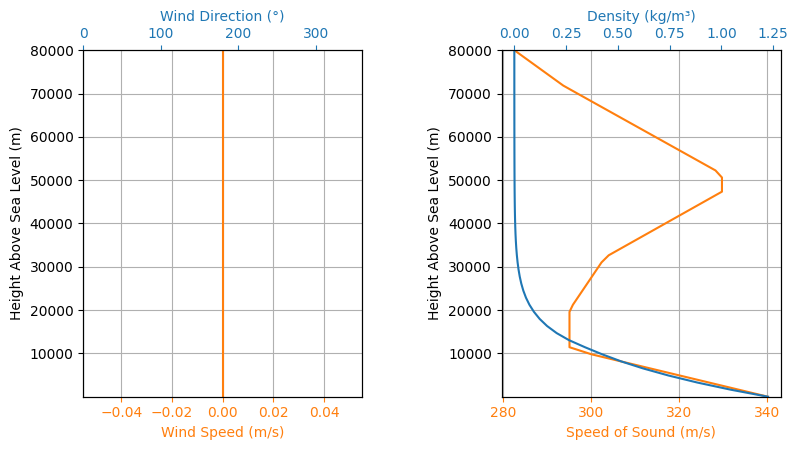

In [3]:
# Run either this cell or the previous cell
# These 2 cells accomplish the same thing in different ways
# This cell type is set to "Raw"

# GRAVITY_MidlandTX = 9.79207    # [ms^-2]

wyoming_sounding_URL = "https://weather.uwyo.edu/cgi-bin/sounding?region=naconf&TYPE=TEXT%3ALIST&YEAR=2025&MONTH=11&FROM=2712&TO=2712&STNM=72265"


env = Environment(
    latitude=LATITUDE_MidlandTX, 
    longitude=-LONGITUDE_MidlandTX,
    elevation=ELEVATION_MidlandTX,
    timezone=TIMEZONE_MidlandTX)

env = Environment(
    latitude=LATITUDE_PALMBAY_FL,
    longitude=LONGITUDE_PALMBAY_FL,
    elevation=ELEVATION_PALMBAY_FL,
    timezone=TIMEZONE_PALMBAY_FL)

env.set_elevation('Open-Elevation')
env.info()

env.set_date((launch_date.year, launch_date.month, launch_date.day, 12))  # Hour given in UTC time
env.set_atmospheric_model(type="wyoming_sounding",
                          file=wyoming_sounding_URL)



**BUILDING THE MOTOR**

In [ ]:
M1939W = SolidMotor(
    thrust_source="AeroTech_M1939W.eng",
    dry_mass=3.33,  # kg
    dry_inertia=(0.148, 0.148, 0.00392),
    nozzle_radius=0.009325,  # m
    grain_number=4,
    grain_density=1709,  # kg/m3
    grain_outer_radius=0.0427355,  # m
    grain_initial_inner_radius=0.0142875,  # m
    grain_initial_height=0.1524,  # m
    grain_separation=0.01,  # m
    grains_center_of_mass_position=0.366,  # m
    center_of_dry_mass_position=0.366,  # m
    nozzle_position=0,
    burn_time=6.23,  # s
    coordinate_system_orientation="nozzle_to_combustion_chamber",
    )

**BUILDING THE ROCKET**

In [ ]:
I = (4.656,4.656,0.088)  # kg*m2

rocket = Rocket(
    radius=0.157/2, # m
    mass=18.3,  # kg
    inertia= I, #(4.656,4.656,0.088), kg*m2
    power_off_drag="Cd_vs_Mach_openrocket_clean.csv",
    power_on_drag="Cd_vs_Mach_openrocket_clean.csv",
    center_of_mass_without_motor=1.65,  # m
    coordinate_system_orientation="nose_to_tail",
    )

rocket.add_motor(M1939W,position=2.9)

**ADDING NOSE CONE**

In [ ]:
nose_cone=rocket.add_nose(
    length=0.762,
    kind="lvhaack",
    position=0.0
    )

**ADDING THE FINS**

In [ ]:
fin_set=rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.356,    # [m]
    tip_chord=0.051,    # [m]
    span=0.178,    # [m]
    position=2.49,
    cant_angle=0,    # [deg]
    sweep_length=.254,    # [m]
#    sweep_angle=55,    # [deg]
    )

**ADDING PARCHUTES**

In [ ]:
main = rocket.add_parachute(
    name="main",
    cd_s=9.77,
    trigger=304.8,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    )

drogue = rocket.add_parachute(
    name="drogue",
    cd_s=0.293,
    trigger="apogee",  # ejection at apogee
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    )

**ADDING AIRBRAKES**

In [ ]:
# https://docs.rocketpy.org/en/latest/user/airbrakes.html
# https://docs.rocketpy.org/en/latest/reference/classes/aero_surfaces/AirBrakes.html

# function copied from:  https://docs.rocketpy.org/en/latest/user/airbrakes.html

#    NEED TO FIND/CREATE  "air_brakes_cd.csv"

#air_brakes = rocket.add_air_brakes(
#    drag_coefficient_curve="air_brakes_cd.csv",


# ROCKETPY_EXAMPLE = "airbrakes_drag_coefficient_example_file.csv"
# AIRBRAKES_DRAG_CSV_FILE = ROCKETPY_EXAMPLE




def controller_function(
    time, sampling_rate, state, state_history, observed_variables, air_brakes
):
    # state = [x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    altitude_ASL = state[2]
    altitude_AGL = altitude_ASL - env.elevation
    vx, vy, vz = state[3], state[4], state[5]

    # Get winds in x and y directions
    wind_x, wind_y = env.wind_velocity_x(altitude_ASL), env.wind_velocity_y(altitude_ASL)

    # Calculate Mach number
    free_stream_speed = (
        (wind_x - vx) ** 2 + (wind_y - vy) ** 2 + (vz) ** 2
    ) ** 0.5
    mach_number = free_stream_speed / env.speed_of_sound(altitude_ASL)

    # Get previous state from state_history
    previous_state = state_history[-1]
    previous_vz = previous_state[5]

    # If we wanted to we could get the returned values from observed_variables:
    # returned_time, deployment_level, drag_coefficient = observed_variables[-1]

    # Check if the rocket has reached burnout
    if time < M1939W.burn_out_time:
        return None

    # If below 1500 meters above ground level, air_brakes are not deployed
    #if altitude_AGL < 1500:
    if altitude_AGL < 3048:  # If below 10,000 feet above ground level, air_brakes are not deployed
        air_brakes.deployment_level = 0

    # Else calculate the deployment level
    else:
        # Controller logic
        new_deployment_level = (
            air_brakes.deployment_level + 0.1 * vz + 0.01 * previous_vz**2
        )

        # Limiting the speed of the air_brakes to 0.2 per second
        # Since this function is called every 1/sampling_rate seconds
        # the max change in deployment level per call is 0.2/sampling_rate
        max_change = 0.2 / sampling_rate
        lower_bound = air_brakes.deployment_level - max_change
        upper_bound = air_brakes.deployment_level + max_change
        new_deployment_level = min(max(new_deployment_level, lower_bound), upper_bound)

        air_brakes.deployment_level = new_deployment_level

    # Return variables of interest to be saved in the observed_variables list
    return (
        time,
        air_brakes.deployment_level,
        air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number),
    )



air_brakes = rocket.add_air_brakes(
    drag_coefficient_curve=AIRBRAKES_DRAG_CSV_FILE,  # File location 
    controller_function=controller_function,
    sampling_rate=10,
    reference_area=None,
    clamp=True,
    initial_observed_variables=[0, 0, 0],
    override_rocket_drag=False,
    name="Air Brakes",
)

air_brakes.all_info()



**CREATING TEST LAUNCH**

In [ ]:
test_flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=5.18,
    inclination=83,
    heading=0,
    time_overshoot=False,  # Required for controllers/sensors
    terminate_on_apogee=False,
    )

In [ ]:
import matplotlib.pyplot as plt

time_list, deployment_level_list, drag_coefficient_list = [], [], []

obs_vars = test_flight.get_controller_observed_variables()

for time, deployment_level, drag_coefficient in obs_vars:
    time_list.append(time)
    deployment_level_list.append(deployment_level)
    drag_coefficient_list.append(drag_coefficient)

# Plot deployment level by time
plt.plot(time_list, deployment_level_list)
plt.xlabel("Time (s)")
plt.ylabel("Deployment Level")
plt.title("Deployment Level by Time")
plt.grid()
plt.show()

# Plot drag coefficient by time
plt.plot(time_list, drag_coefficient_list)
plt.xlabel("Time (s)")
plt.ylabel("Drag Coefficient")
plt.title("Drag Coefficient by Time")
plt.grid()
plt.show()

test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
test_flight.altitude()
test_flight.vz()

**CALLING ON SIMULATION FUNCTIONS**

In [ ]:
#rocket.all_info()
#rocket.plots.static_margin()

#rocket.draw()
#print("Trajectory Data")
#test_flight.plots.trajectory_3d()
#print("Kinematics Data")
#test_flight.plots.linear_kinematics_data()
#print("Energy Data")
#test_flight.plots.energy_data()

test_flight.info()

**Prepare for Monte Carlo Simulations**

In [ ]:
from rocketpy import simulation, MonteCarlo
from rocketpy.stochastic import (
    StochasticEnvironment,
    StochasticFlight,
    StochasticNoseCone,
    StochasticParachute,
    #StochasticRailButtons,
    StochasticRocket,
    StochasticSolidMotor,
    #StochasticTail,
    StochasticTrapezoidalFins,
    )

**Create "Stochastic" Version of Everything**

In [ ]:
stochastic_env = StochasticEnvironment(env)
stochastic_env.visualize_attributes()

In [ ]:
stochastic_env = StochasticEnvironment(env)
stochastic_env.visualize_attributes()

stochastic_rocket = StochasticRocket(rocket)
stochastic_rocket.visualize_attributes()

stochastic_motor = StochasticSolidMotor(
    solid_motor=M1939W,
    burn_start_time=(0, 0.1, "binomial"),
    grains_center_of_mass_position=0.001,
    grain_density=10,
    grain_separation=1 / 1000,
    grain_initial_height=1 / 1000,
    grain_initial_inner_radius=0.375 / 1000,
    grain_outer_radius=0.375 / 1000,
    total_impulse=(6500, 100),
    throat_radius=0.5 / 1000,
    nozzle_radius=0.5 / 1000,
    nozzle_position=0.001,
    )
stochastic_motor.visualize_attributes()

stochastic_main_parachute = StochasticParachute(
    parachute=main,
    cd_s=0.1,
    lag=0.1,
    )
stochastic_main_parachute.visualize_attributes()

stochastic_drogue_parachute = StochasticParachute(
    parachute=drogue,
    cd_s=0.07,
    lag=0.2,
    )
stochastic_drogue_parachute.visualize_attributes()

stochastic_fins = StochasticTrapezoidalFins(
    trapezoidal_fins=fin_set,
    root_chord=0.0005,
    tip_chord=0.0005,
    span=0.0005,
    )
stochastic_fins.visualize_attributes()

stochastic_nose_cone = StochasticNoseCone(
    nosecone=nose_cone,
    length=0.001,
    )
stochastic_nose_cone.visualize_attributes()

stochastic_rocket.add_motor(stochastic_motor, position=0.001)
stochastic_rocket.add_nose(stochastic_nose_cone, position=(1.134, 0.001))
stochastic_rocket.add_trapezoidal_fins(stochastic_fins, position=(0.001, "normal"))
stochastic_rocket.add_parachute(stochastic_main_parachute)
stochastic_rocket.add_parachute(stochastic_drogue_parachute)

stochastic_flight = StochasticFlight(
    flight=test_flight,
    inclination=(83, 1),  # mean= 83, std=1
    heading=(0, 2),  # mean= 0, std=2
    )
#stochastic_flight.visualize_attributes()


**Create Monte Carlo Simulation**

In [ ]:
#rocket.all_info()
#rocket.plots.static_margin()
#rocket.draw()
print("Trajectory Data")
stochastic_flight.plots.trajectory_3d()
print("Kinematics Data")
stochastic_flight.plots.linear_kinematics_data()
print("Energy Data")
#stochastic_flight.plots.energy_data()
stochastic_flight.info()

In [ ]:

test_dispersion = MonteCarlo(
    filename="monte_carlo_analysis_outputs",
    environment=stochastic_env,
    rocket=stochastic_rocket,
    flight=stochastic_flight,
    )

test_dispersion.simulate(
    number_of_simulations=10,
    append=False,
    include_function_data=False,
    #parallel=True,
    #n_workers=4,
    )

test_dispersion.prints.all()
test_dispersion.plots.all()

**Export Google Earth KML file**

In [ ]:
test_dispersion.export_ellipses_to_kml(
    filename="monte_carlo_output.kml",
    origin_lat=env.latitude,
    origin_lon=env.longitude,
    type="impact",
    )